In [2]:
import pandas as pd

df = pd.read_csv("/workspaces/Proyecto_Final/data/processed/vehicles_with_model_clean.csv")

df.head()

,price,year,manufacturer,model,fuel,odometer,transmission,drive,size,type,state,lat,long
0,22590,2010.0,chevrolet,silverado,gas,71229.0,other,4wd,full-size,pickup,al,32.5900,-85.480000
1,30990,2017.0,toyota,tundra,gas,41124.0,other,4wd,full-size,pickup,al,32.5900,-85.480000
2,15000,2013.0,ford,f150,gas,128000.0,automatic,rwd,full-size,truck,al,32.5920,-85.518900
3,35000,2019.0,toyota,tacoma,gas,43000.0,automatic,4wd,mid-size,truck,al,32.6013,-85.443974
4,29990,2016.0,chevrolet,colorado,gas,17302.0,other,4wd,mid-size,pickup,al,32.5900,-85.480000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301061 entries, 0 to 301060
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         301061 non-null  int64  
 1   year          301061 non-null  float64
 2   manufacturer  301061 non-null  object 
 3   model         301061 non-null  object 
 4   fuel          301061 non-null  object 
 5   odometer      301061 non-null  float64
 6   transmission  301061 non-null  object 
 7   drive         301061 non-null  object 
 8   size          301061 non-null  object 
 9   type          301061 non-null  object 
 10  state         301061 non-null  object 
 11  lat           301061 non-null  float64
 12  long          301061 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 29.9+ MB


In [4]:
#separar las columnas numericas y categoricas y la columna objetivo
target = df["price"]
num_cols = ["year", "odometer", "lat", "long"]
cat_cols = ["manufacturer", "model", "fuel", "transmission", "drive", "size", "type", "state"]



In [5]:
#analizar las columnas numericas
df[num_cols].describe()

,year,odometer,lat,long
count,301061.000000,301061.000000,301061.000000,301061.000000
mean,2010.904122,99025.488203,38.588224,-94.727636
std,8.597463,57622.322744,5.926847,18.570241
min,1900.000000,0.000000,-81.838232,-159.827728
25%,2008.000000,52000.000000,34.951231,-111.914160
50%,2013.000000,97937.000000,39.313577,-88.807800
75%,2016.000000,140000.000000,42.469437,-80.759936
max,2022.000000,250000.000000,82.252826,173.885502


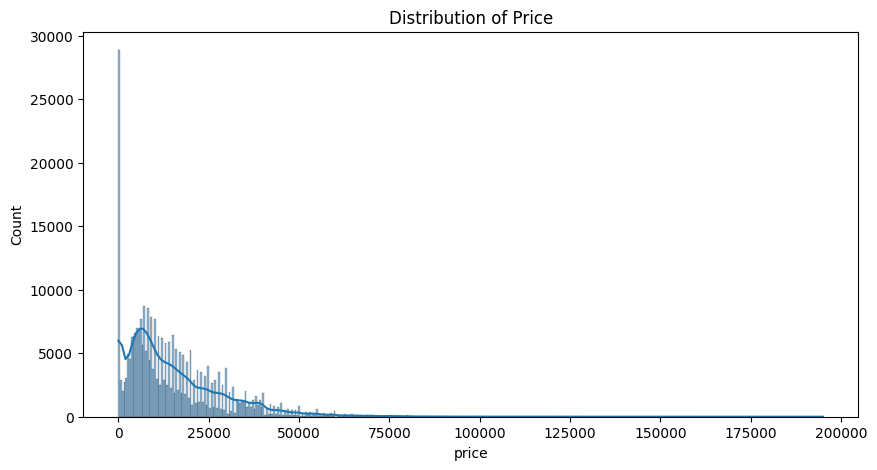

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
#visualizacion columna objetivo
plt.figure(figsize=(10, 5))
sns.histplot(target, kde=True)
plt.title('Distribution of Price')
plt.show()

In [28]:
#count registerst with price = 0
precio_cero = df[df["price"] == 0]
print(len(precio_cero))

21866


In [34]:
#drop registers with price = 0
df = df[df["price"] != 0]

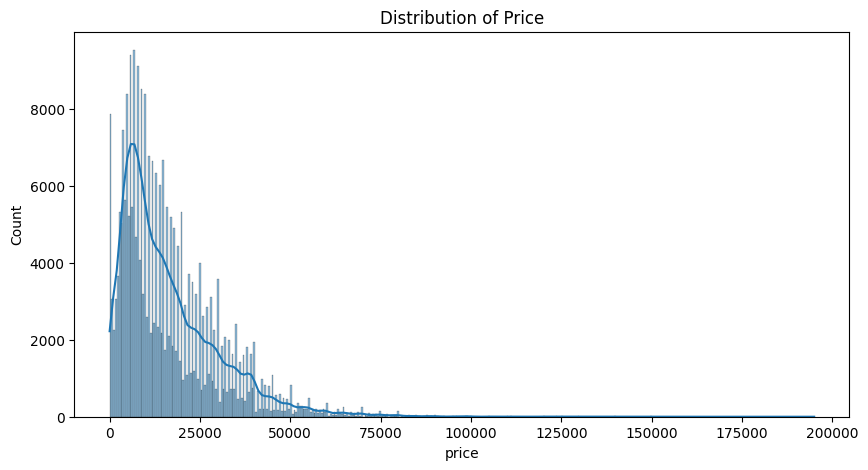

In [35]:
#visualizar nuevamente price
target = df["price"]
plt.figure(figsize=(10, 5))
sns.histplot(target, kde=True)
plt.title('Distribution of Price')
plt.show()

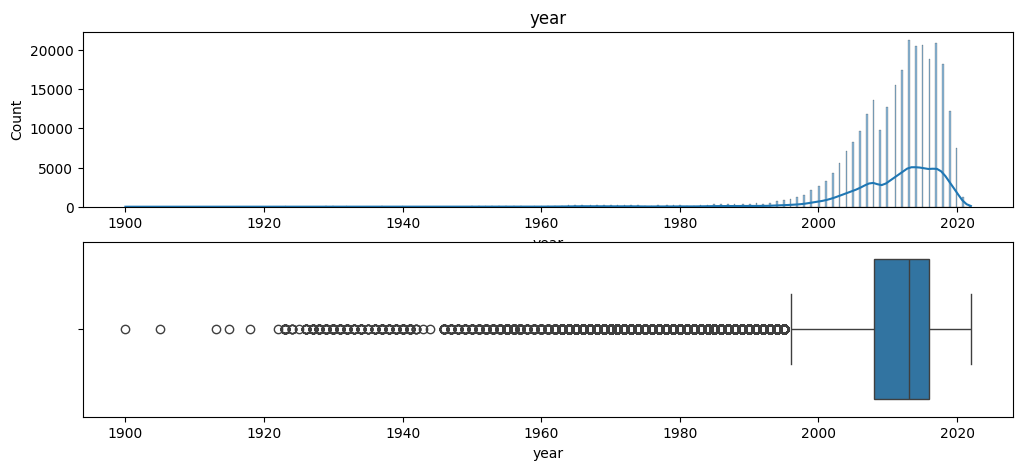

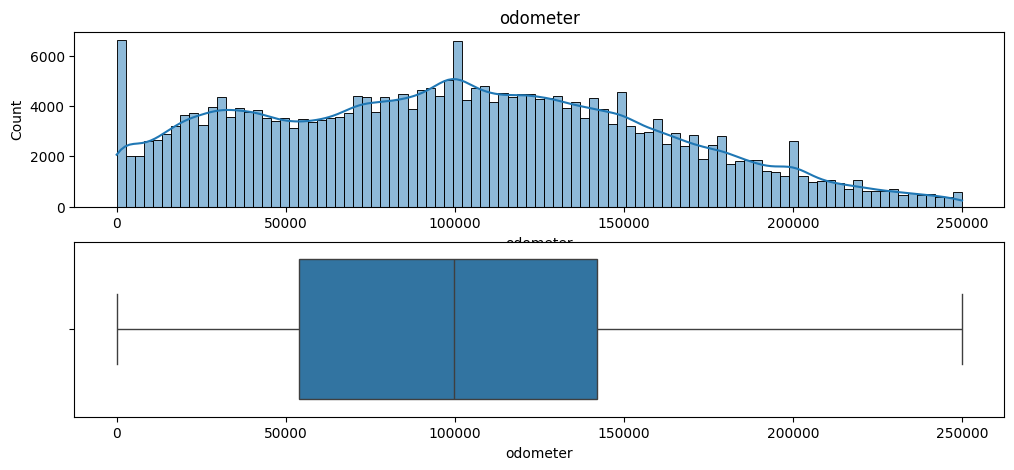

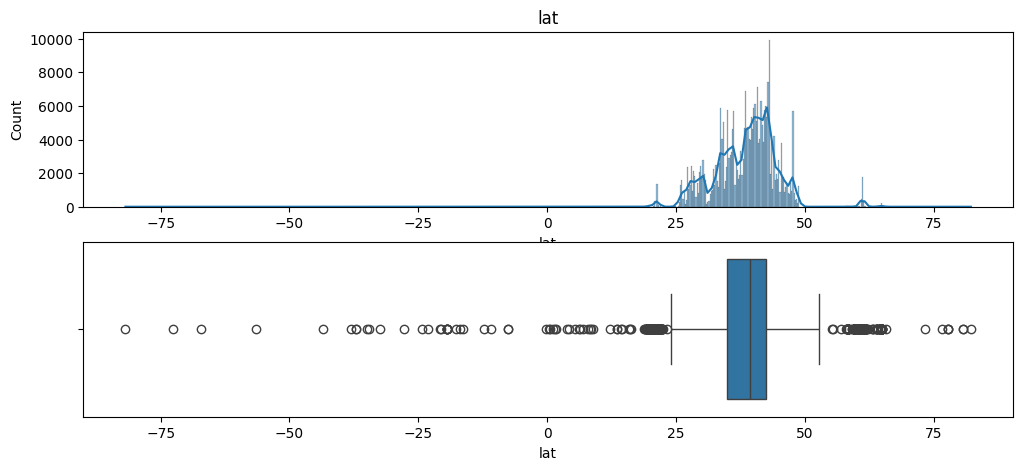

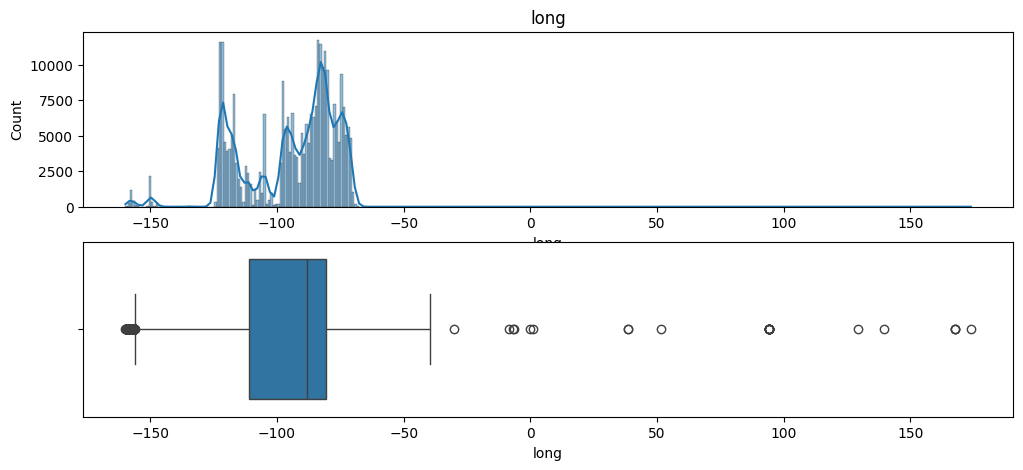

In [30]:

#visualizacion

for columna in num_cols:
    plt.figure(figsize=(12, 5))

    # Histograma
    plt.subplot(2, 1, 1)
    sns.histplot(df[columna], kde=True)
    plt.title(f'{columna}')

    # Boxplot
    plt.subplot(2, 1, 2)
    sns.boxplot(x=df[columna])

    plt.show()

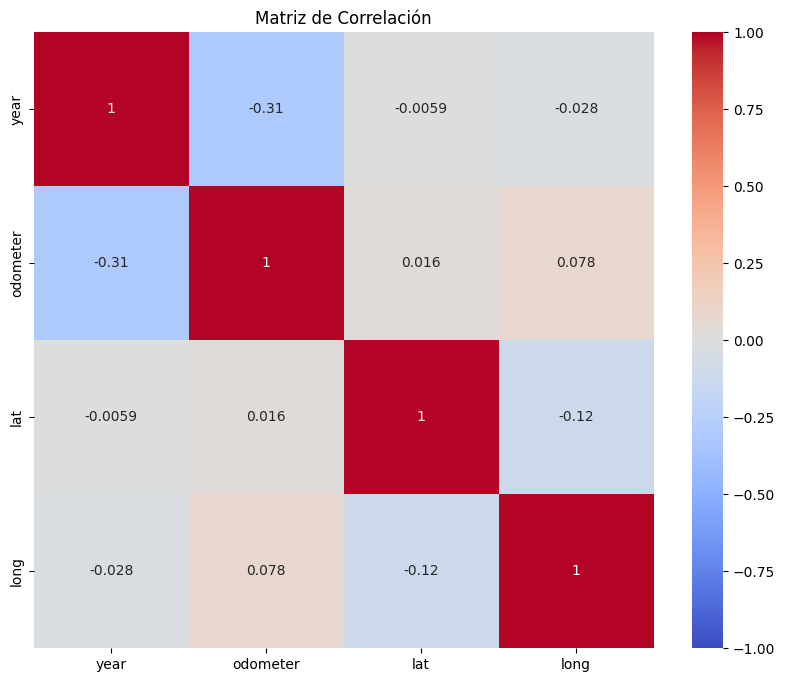

In [7]:
#matriz de correlacion
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

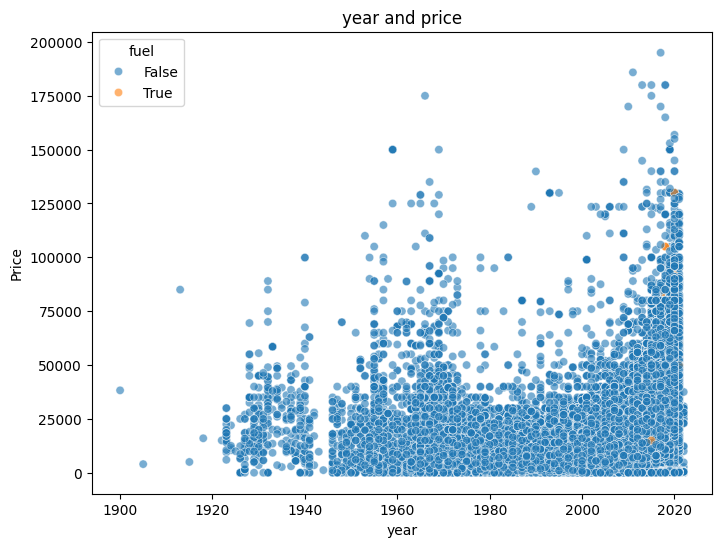

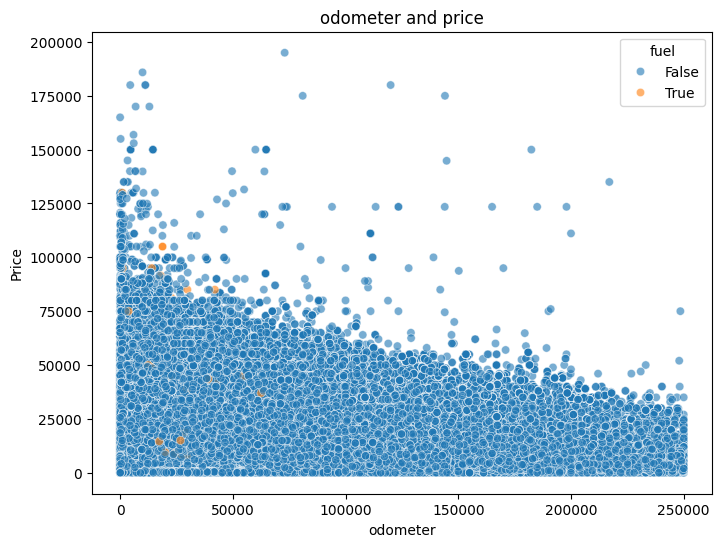

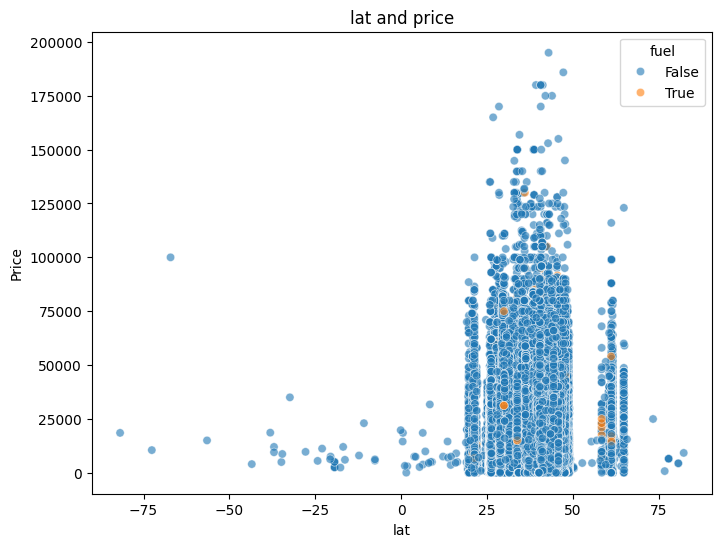

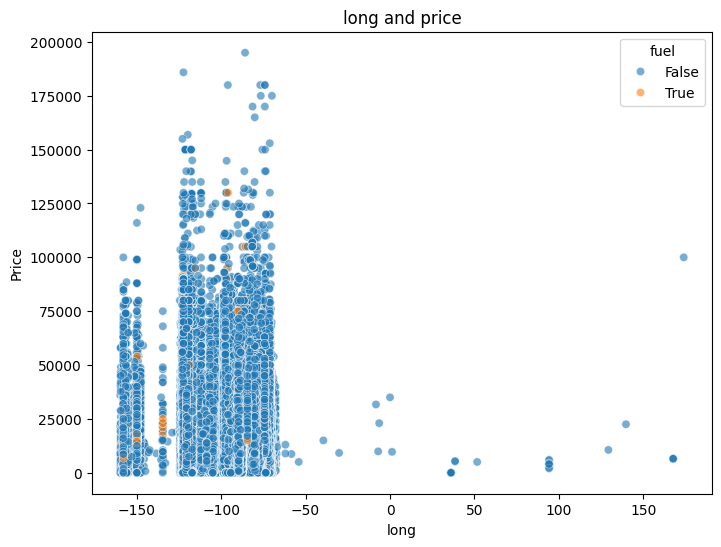

In [13]:
#analizar relacion entre columnas numericas y columna objetivo
electric = df["fuel"] == "electric"

for columna in num_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[columna], y= target, alpha=0.6, hue=electric)
    plt.title(f'{columna} and price')
    plt.xlabel(columna)
    plt.ylabel("Price")
    plt.show() 